# Assignment 2: Milestone I Natural Language Processing
## Task 2&3
#### Student Name: XXXX XXXX
#### Student ID: 000000


Environment: Python 3 and Jupyter notebook

Libraries used: please include all the libraries you used in your assignment, e.g.,:
* pandas
* re
* numpy

## Introduction
You should give a brief information of this assessment task here.

<span style="color: red"> Note that this is a sample notebook only. You will need to fill in the proper markdown and code blocks. You might also want to make necessary changes to the structure to meet your own needs. Note also that any generic comments written in this notebook are to be removed and replace with your own words.</span>

## Install fasttest used for vector embedding

In [3]:
!pip install --upgrade pip setuptools wheel
!pip install fasttext-wheel


   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 837.5 kB/s eta 0:00:02
   ----------------- ---------------------- 0.8/1.8 MB 985.5 kB/s eta 0:00:01
   ----------------------- ---------------- 1.0/1.8 MB 1.0 MB/s eta 0:00:01
   ----------------------------- ---------- 1.3/1.8 MB 1.1 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 1.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   -------- ------------------------------- 0.3/1.2 MB ? eta -:--:--
   ----------------- ---------------------- 0.5/1.2 MB 1.4 MB/s eta 0:00:01
   -------------------------- ------------- 0.8/1.2 MB 1.3 MB/s eta 0:00:01
   ---------------------------------------- 1.2/1.

ERROR: To modify pip, please run the following command:
C:\Users\user\anaconda3\python.exe -m pip install --upgrade pip setuptools wheel


## Importing libraries 

In [1]:
# Code to import libraries as you need in this assessment, e.g.,
import pandas as pd
import ast
from collections import Counter
from gensim.models.fasttext import FastText
import ast
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

## Task 2. Generating Feature Representations for Clothing Items Reviews

...... Sections and code blocks on buidling different document feature represetations


<span style="color: red"> You might have complex notebook structure in this section, please feel free to create your own notebook structure. </span>

### Load neccessary csv 
processed.csv

In [70]:
# Code to perform the task...
# === Task 2: Bag-of-Words ===

# Load processed.csv (must contain column 'tokens' from Task 1)
df = pd.read_csv("processed.csv")

# Convert 'tokens' from string to list if needed
print("[OK] processed.csv loaded. Rows:", len(df))

[OK] processed.csv loaded. Rows: 19662


### Building the Vocabulary Dictionary

reading the vocabulary.txt file and building a dictionary that maps each word to its index.

In [71]:
# === Task 2: Bag-of-Words ===
word2idx = {}
with open("vocabulary.txt", "r", encoding="utf-8") as f:
    for line in f:
        s = line.strip()
        if not s:
            continue
        w, sidx = s.rsplit(":", 1)
        word2idx[w] = int(sidx)

print("vocabulary.txt loaded. Size:", len(word2idx))
print("Sample entries:", list(word2idx.items())[:5])

vocabulary.txt loaded. Size: 7529
Sample entries: [('a-cup', 0), ('a-flutter', 1), ('a-frame', 2), ('a-kind', 3), ('a-line', 4)]


### Saving outputs
Save the count vector representation as per spectification.
- count_vectors.txt

In [72]:
# code to save output data...
# === Task 2: Bag-of-Words ===
from collections import Counter

out_path = "count_vectors.txt"

with open(out_path, "w", encoding="utf-8") as fout:
    for review_index, tokens in enumerate(df["tokens"].values):
        ctr = Counter()
        tokens = ast.literal_eval(tokens)
        for t in tokens:
            idx = word2idx.get(t)
            if idx is not None:
                ctr[idx] += 1

        # Format: "#<review_index>,idx:count,idx:count,..."
        
        parts = [f"{i}:{ctr[i]}" for i in sorted(ctr)]
        fout.write(f"#{review_index},{','.join(parts)}\n")

print(f"[OK] Wrote {len(df)} lines to {out_path}")
with open(out_path, "r", encoding="utf-8") as f:
    for _ in range(3):
        print(f.readline().rstrip())

[OK] Wrote 19662 lines to count_vectors.txt
#0,686:1,1027:1,1715:1,1791:1,2288:1,2481:1,2602:1,2892:2,3010:1,3087:1,3193:1,3258:1,3549:2,3552:1,3832:1,3934:1,4224:2,4234:1,4427:1,4639:2,5260:1,5668:1,6726:1,7092:1,7207:1,7406:1,7520:1,7522:1
#1,1286:1,2283:1,2502:1,2667:1,3403:1,6739:1
#2,86:1,924:1,1987:1,2646:1,3584:1,3595:1,4506:1,5736:2,5924:1,6716:1


### Extract the feature vector for each review
#### Unweigted Fasttext model

##### Print out dataframe tokens column's type

In [73]:
print(type(df['tokens'].iloc[0]))

<class 'str'>


##### Create a corpus file  
The corpus file represents distinct words of tokens, which will be used in the following steps.

In [74]:
with open("corpus.txt", "w", encoding="utf-8") as f:
    for tokens_str in df['tokens']:
        tokens_list = ast.literal_eval(tokens_str)
        f.write(" ".join(tokens_list) + "\n")

Now we train the skipgram fasttext model based on the corpus file

In [209]:
model = FastText(
    vector_size=100,
    window=5,
    min_count=1,
    min_n=3,      # smallest ngram
    max_n=6,      # largest ngram
    sg=1          # 1=skipgram, 0=CBOW
)
model.build_vocab(corpus_file="corpus.txt")
model.train("corpus.txt", epochs=model.epochs, total_examples=model.corpus_count, total_words=model.corpus_total_words)

(0, 50)

Try to print out sentence vector of one line to see the format

In [210]:
sentence = df['tokens'].iloc[0]
print(model.wv[sentence])

[ 4.50669526e-04  1.71888620e-04  9.89509499e-05  2.32474020e-04
 -1.32498171e-04  3.75794625e-04  2.04228927e-05  2.61239737e-04
 -1.05362615e-05  5.54911210e-04 -2.00700655e-04 -1.18753742e-04
  3.78287979e-04  1.87281676e-05 -2.66657589e-04 -1.00783618e-04
 -3.96071962e-04 -4.56880487e-04  5.55309583e-04 -1.32876366e-05
  4.09248576e-04  7.15056449e-05 -2.65332084e-04 -2.21251641e-04
  6.04184752e-04 -4.85980272e-05 -6.50871516e-05 -1.94361695e-04
  3.81612481e-04 -1.89477782e-04  2.05938377e-05  5.18298126e-04
  2.72417274e-05  4.65759920e-04  4.86508943e-05  5.39123837e-04
 -4.71081221e-05 -4.34386369e-04 -2.66578718e-05  7.16915820e-04
  4.59734620e-05  1.30255321e-05  2.36555934e-04  3.26444133e-04
 -4.89502738e-04  3.96966498e-04 -8.24999763e-04  1.51743341e-04
  2.44122348e-04 -2.58713349e-04 -1.09271728e-04  1.74100467e-04
 -1.72096770e-04  1.54094669e-04  6.47085311e-04 -2.48585216e-04
  1.60871408e-04  7.57143775e-04 -5.51436911e-04 -2.12418381e-04
  8.63725436e-05  3.63141

Save the result to a column

In [251]:
def get_review_vector(tokens, lang_model):
    words = ast.literal_eval(tokens)
    # keep only words in model's vocab
    word_vecs = [lang_model.wv[word] for word in words if word in lang_model.wv]
    return np.mean(word_vecs, axis=0) if word_vecs else np.zeros(lang_model.vector_size)

# Apply to DataFrame
df["unweighted_vector"] = df["tokens"].apply(get_review_vector, lang_model=model)

df["unweighted_vector"].head()

0    [-0.00032479395, 1.8707953e-05, 7.3741685e-05,...
1    [0.001152432, -0.0007564693, 0.000613518, 0.00...
2    [6.7829526e-05, 0.0001359482, -0.00043854406, ...
3    [-0.00013552177, 0.00017135871, 0.00017746724,...
4    [-0.0011166261, 0.0007340111, 0.00081652985, -...
Name: unweighted_vector, dtype: object

Save to a txt file with correct format

In [252]:
out_path = "unweighted_vectors.txt"

lines = []
for review_index, vec in enumerate(df["unweighted_vector"].values):
    if hasattr(vec, "tolist"):
        vec = vec.tolist()
    lines.append(f"#{review_index},[{','.join(map(str, vec))}]\n")

with open(out_path, "w", encoding="utf-8") as fout:
    fout.writelines(lines)

print(f"[OK] Wrote {len(lines)} lines to {out_path}")


[OK] Wrote 19662 lines to unweighted_vectors.txt


Reload the corpus for TF-IDF fit transformation

In [254]:

import numpy as np
from gensim.corpora import Dictionary
from gensim.models import TfidfModel
from gensim.matutils import sparse2full


def get_tfidf_vector(sentences, embedding_dim, model):
    tokens = [s.split() for s in sentences]

    # Build dictionary
    docs_dict = Dictionary(tokens)
    docs_dict.compactify()  # remove gaps in ids
    
    # Convert documents to BoW representation
    docs_corpus = [docs_dict.doc2bow(doc) for doc in tokens]

    # Fit TF-IDF model
    model_tfidf = TfidfModel(docs_corpus, id2word=docs_dict)

    # Apply TF-IDF to corpus
    docs_tfidf = model_tfidf[docs_corpus]

    # Prepare embedding matrix
    doc_vectors = np.zeros((len(docs_tfidf), embedding_dim))
    
    # For each document, compute weighted embedding
    for i, doc in enumerate(docs_tfidf):
        if not doc:
            continue
        
        weighted_sum = np.zeros(embedding_dim, dtype=np.float32)
        weight_sum = 0.0
        
        for idx, weight in doc:
            word = docs_dict[idx]  # get actual token
            if word in model.wv:   # check word exists in embeddings
                vec = model.wv[word]
                weighted_sum += vec * weight
                weight_sum += weight
        
        if weight_sum > 0:
            doc_vectors[i] = weighted_sum / weight_sum
    
    return doc_vectors

In [255]:
# load corpus into sentences for vectorizer
with open("corpus.txt", "r", encoding="utf-8") as f:
    sentences = [line.strip() for line in f]

doc_vectors = get_tfidf_vector(sentences, embedding_dim=model.vector_size, model=model)

Use TF-IDF weight to vectorize the tokens

Save the result

In [256]:
df["weighted_vector"] = [vec.tolist() for vec in doc_vectors]
df.head()

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,tokens,unweighted_vector,weighted_vector
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,"['high', 'hopes', 'wanted', 'work', 'initially...","[-0.00032479395, 1.8707953e-05, 7.3741685e-05,...","[-0.0001471141877118498, -4.248036930221133e-0..."
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,"['jumpsuit', 'fun', 'flirty', 'fabulous', 'tim...","[0.001152432, -0.0007564693, 0.000613518, 0.00...","[0.0013227021554484963, -0.0008015964413061738..."
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,"['shirt', 'due', 'adjustable', 'front', 'tie',...","[6.7829526e-05, 0.0001359482, -0.00043854406, ...","[-3.7504014471778646e-05, 0.000228192104259505..."
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",2,0,4,General,Dresses,Dresses,"['tracy', 'reese', 'dresses', 'petite', 'feet'...","[-0.00013552177, 0.00017135871, 0.00017746724,...","[-0.00012622457870747894, 0.000162914322572760..."
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,5,1,1,General Petite,Tops,Knits,"['basket', 'hte', 'person', 'store', 'pick', '...","[-0.0011166261, 0.0007340111, 0.00081652985, -...","[-0.001333603635430336, 0.0005755956517532468,..."


In [257]:
out_path = "weighted_vectors.txt"

with open(out_path, "w", encoding="utf-8") as fout:
    for review_index, vec_str in enumerate(df["weighted_vector"].values):
        # Convert string "[0.1, 0.2, ...]" into Python list
        fout.write(f"#{review_index}," + ",".join(map(str, vec_str)) + "\n")

print(f"[OK] Wrote {len(df)} lines to {out_path}")

# Preview first 3 lines
with open(out_path, "r", encoding="utf-8") as f:
    for _ in range(3):
        print(f.readline().rstrip())

[OK] Wrote 19662 lines to weighted_vectors.txt
#0,-0.0001471141877118498,-4.248036930221133e-05,0.0001858971663750708,0.00039884421858005226,-0.00019153101311530918,-0.00016308471094816923,-6.02539221290499e-05,0.000246835348661989,-6.370753544615582e-05,-2.5670776722108712e-06,-9.470966324442998e-05,-0.0004407095839269459,-0.00024694521562196314,-0.00043992383871227503,-5.987279655528255e-05,-8.381916995858774e-05,-0.00021312659373506904,-0.00046588751138187945,7.950236067699734e-06,0.00014523311983793974,-7.749898213660344e-05,0.0003675682528410107,-0.000533438753336668,0.0006650241557508707,5.725819937651977e-05,0.0003132254641968757,7.58744718041271e-05,0.00017263567133340985,9.837820834945887e-05,-0.0006503960466943681,0.0003937934816349298,0.0003483483160380274,-6.833497172920033e-05,4.7710250328236725e-06,-5.499968392541632e-05,0.0006584758521057665,-8.456701471004635e-05,-0.0002617736463434994,8.14576560514979e-05,0.00013881264021620154,0.0001480653154430911,-7.874563743826002e

## Task 3. Clothing Review Classification

...... Sections and code blocks on buidling classification models based on different document feature represetations. 
Detailed comparsions and evaluations on different models to answer each question as per specification. 

<span style="color: red"> You might have complex notebook structure in this section, please feel free to create your own notebook structure. </span>

In [258]:
# Code to perform the task...
def load_vectors(file_path, sparse=False):
    vectors = []
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split(",", 1)
            if len(parts) < 2:
                continue
            vec_str = parts[1]
            if sparse:
                vec = {}
                for item in vec_str.split(","):
                    if ":" in item:
                        idx, val = item.split(":")
                        vec[int(idx)] = int(val)
                vectors.append(vec)
            else:
                vec_str = vec_str.strip("[]")
                vec = np.array([float(x) for x in vec_str.split(",")])
                vectors.append(vec)
    return vectors


In [259]:
from sklearn.preprocessing import StandardScaler


X_count     = load_vectors("count_vectors.txt", sparse=True)
X_ft_unweighted = StandardScaler().fit_transform(np.array(load_vectors("unweighted_vectors.txt")))
X_ft_weighted   = StandardScaler().fit_transform(np.array(load_vectors("weighted_vectors.txt")))

In [260]:
X_unweighted

array([[ 0.9726105 , -0.03525018, -0.6455133 , ...,  0.32141874,
         0.32746208,  0.55342281],
       [ 2.34858928,  3.64470197,  0.6222747 , ..., -0.8324083 ,
        -1.58623044,  2.10726639],
       [ 0.77242044, -1.25055221, -0.73065871, ..., -0.57239801,
        -0.1256593 ,  1.46883514],
       ...,
       [ 3.63656706, -2.97766325, -2.37270738, ..., -0.99090324,
         2.24764952, -1.20472748],
       [ 0.09196857,  0.14647368,  0.17309027, ...,  0.77616885,
         0.48668827, -0.47178844],
       [ 0.02965841, -1.74899605, -0.44770876, ..., -0.30362557,
        -0.00429756, -0.7260753 ]])

In [261]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier


cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
clf = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier(
        n_estimators=200,        # number of trees
        max_depth=None,          # let trees grow fully
        class_weight="balanced", # handle imbalance
        random_state=42,
        n_jobs=-1
)

In [262]:
y = df["Recommended IND"].values  

In [88]:
df["Recommended IND"].value_counts()

Recommended IND
1    16087
0     3575
Name: count, dtype: int64

In [263]:
print(X_unweighted)

[[ 0.9726105  -0.03525018 -0.6455133  ...  0.32141874  0.32746208
   0.55342281]
 [ 2.34858928  3.64470197  0.6222747  ... -0.8324083  -1.58623044
   2.10726639]
 [ 0.77242044 -1.25055221 -0.73065871 ... -0.57239801 -0.1256593
   1.46883514]
 ...
 [ 3.63656706 -2.97766325 -2.37270738 ... -0.99090324  2.24764952
  -1.20472748]
 [ 0.09196857  0.14647368  0.17309027 ...  0.77616885  0.48668827
  -0.47178844]
 [ 0.02965841 -1.74899605 -0.44770876 ... -0.30362557 -0.00429756
  -0.7260753 ]]


In [264]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns


def run_model_analysis(model, X_count, X_unweighted, X_weighted, y):

    for name, X in [("Count", X_count), ("Unweighted", X_unweighted), ("Weighted", X_weighted)]:
        # if X_count is dict format, convert with DictVectorizer
        if name == "Count":
            vec = DictVectorizer(sparse=True)
            X = vec.fit_transform(X)

        print(f"\n=== Using {name} Vectors ===")
        y_pred = cross_val_predict(model, X, y, cv=cv)
        # Accuracy
        acc = accuracy_score(y, y_pred)
        print(f"Accuracy: {acc:.3f}")
        
        # Detailed report
        print(classification_report(y, y_pred, digits=3))
        
        # Confusion matrix
        cm = confusion_matrix(y, y_pred)
        print("Confusion Matrix:")
        print(cm)

        # --- Plot confusion matrix ---
        plt.figure(figsize=(5,4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                    xticklabels=["Not Recommended", "Recommended"],
                    yticklabels=["Not Recommended", "Recommended"])
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.title(f"Confusion Matrix ({name} Vectors)")
        plt.show()

In [ ]:
run_model_analysis(rf, X_count, X_ft_unweighted, X_ft_weighted, y)


=== Using Count Vectors ===


Try Word2Net

In [266]:
from gensim.models.word2vec import Word2Vec


w2v_model = w2v_model = Word2Vec(
    vector_size=100,   # embedding size
    window=5,          # context window
    min_count=2,       # ignore very rare words
    sg=1,              # 1=Skip-gram, 0=CBOW
    workers=4,         # parallel training
    epochs=10
)
w2v_model.build_vocab(corpus_file="corpus.txt")
w2v_model.train("corpus.txt", epochs=w2v_model.epochs, total_examples=w2v_model.corpus_count, total_words=w2v_model.corpus_total_words)

(0, 100)

In [267]:
df["tokens"]

0        ['high', 'hopes', 'wanted', 'work', 'initially...
1        ['jumpsuit', 'fun', 'flirty', 'fabulous', 'tim...
2        ['shirt', 'due', 'adjustable', 'front', 'tie',...
3        ['tracy', 'reese', 'dresses', 'petite', 'feet'...
4        ['basket', 'hte', 'person', 'store', 'pick', '...
                               ...                        
19657    ['happy', 'snag', 'price', 'easy', 'slip', 'cu...
19658    ['reminds', 'maternity', 'clothes', 'stretchy'...
19659       ['worked', 'glad', 'store', 'order', 'online']
19660    ['wedding', 'summer', 'medium', 'fits', 'waist...
19661    ['lovely', 'feminine', 'fits', 'perfectly', 'e...
Name: tokens, Length: 19662, dtype: object

In [268]:
w2v_unweighted_data = df["tokens"].apply(get_review_vector, lang_model=w2v_model)

In [269]:
w2v_unweighted_data

0        [0.0011712925, -0.000597283, -0.0005311198, 0....
1        [0.004438915, 0.0042267796, 0.0012926561, -0.0...
2        [0.003057477, -0.0012979076, -0.00071185327, -...
3        [0.0007561769, -0.0007998743, 0.00092076993, 0...
4        [-0.0004059592, 0.0006870339, 0.0003819962, 0....
                               ...                        
19657    [0.00013883086, 0.002899377, 0.0020263323, -0....
19658    [-0.00065233634, 0.0013486886, 0.0007128672, 0...
19659    [0.0050244564, -0.0030226666, -0.005793617, -0...
19660    [0.00062641694, -0.00040732374, 5.7780406e-05,...
19661    [-8.663218e-05, -0.0026997603, -0.0006973918, ...
Name: tokens, Length: 19662, dtype: object

In [270]:
# load corpus into sentences for vectorizer
with open("corpus.txt", "r", encoding="utf-8") as f:
    sentences = [line.strip() for line in f]

doc_vectors = get_tfidf_vector(sentences, embedding_dim=w2v_model.vector_size, model=w2v_model)
w2v_weighted_data = [vec.tolist() for vec in doc_vectors]


In [271]:
w2v_weighted_data


[[0.0011728936806321144,
  -0.00016492734721396118,
  -0.0009865474421530962,
  0.00018562364857643843,
  -0.0001350374659523368,
  -0.0015509506920352578,
  0.0013442332856357098,
  0.0016573992324993014,
  -0.0020010550506412983,
  -0.00031242394470609725,
  -0.001632387051358819,
  -0.000766474346164614,
  -0.0009584461222402751,
  -0.00047268718481063843,
  0.0014148111222311854,
  -0.001828855718486011,
  -0.0002813413739204407,
  -0.0008000482339411974,
  0.0002762011135928333,
  -0.0001958246430149302,
  8.735203300602734e-05,
  0.0017008435679599643,
  -0.0017364529194310308,
  0.0002571146469563246,
  0.0014451135648414493,
  0.0018543341429904103,
  0.0001166859146906063,
  0.0002645690692588687,
  -0.00015675277973059565,
  0.0005880441749468446,
  -0.0009951951215043664,
  0.001316499779932201,
  -0.0005420016241259873,
  -0.0021362286061048508,
  -0.0011578743578866124,
  0.002065734937787056,
  -0.002874185098335147,
  -0.002576548606157303,
  0.00032633778755553067,
  -0

In [272]:
X_w2v_unweighted = StandardScaler().fit_transform(np.vstack(w2v_unweighted_data))
X_w2v_weighted   = StandardScaler().fit_transform(np.vstack(w2v_weighted_data))



=== Using Count Vectors ===
Accuracy: 0.876
              precision    recall  f1-score   support

           0      0.706     0.549     0.617      3575
           1      0.904     0.949     0.926     16087

    accuracy                          0.876     19662
   macro avg      0.805     0.749     0.772     19662
weighted avg      0.868     0.876     0.870     19662

Confusion Matrix:
[[ 1962  1613]
 [  819 15268]]


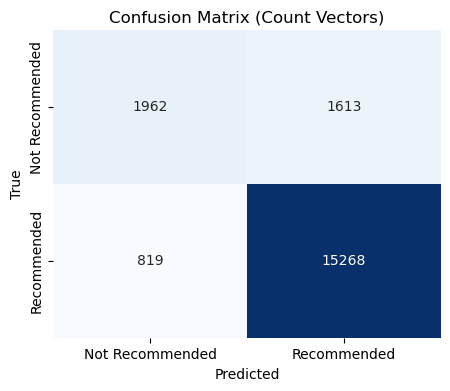


=== Using Unweighted Vectors ===
Accuracy: 0.821
              precision    recall  f1-score   support

           0      0.545     0.085     0.147      3575
           1      0.829     0.984     0.900     16087

    accuracy                          0.821     19662
   macro avg      0.687     0.535     0.523     19662
weighted avg      0.777     0.821     0.763     19662

Confusion Matrix:
[[  304  3271]
 [  254 15833]]


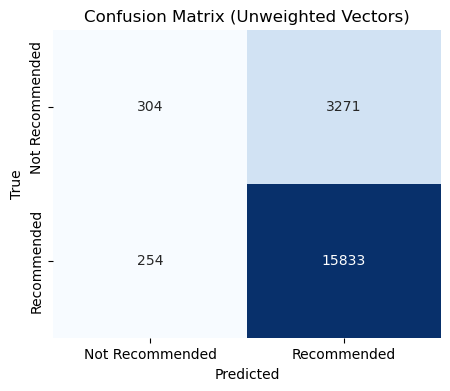


=== Using Weighted Vectors ===
Accuracy: 0.818
              precision    recall  f1-score   support

           0      0.508     0.045     0.083      3575
           1      0.824     0.990     0.899     16087

    accuracy                          0.818     19662
   macro avg      0.666     0.518     0.491     19662
weighted avg      0.766     0.818     0.751     19662

Confusion Matrix:
[[  161  3414]
 [  156 15931]]


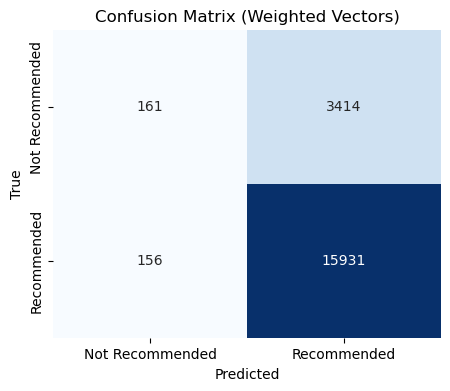

In [273]:
run_model_analysis(clf, X_count, X_w2v_unweighted, X_w2v_weighted, y)

### Q2: Does more information provide higher accuracy?  
#### Title only data

In [ ]:
from nltk.tokenize import RegexpTokenizer

df = pd.read_csv('assignment3.csv')
# 2/3/4. Tokenizing clothing review

# define tokenizer
tokenizer = RegexpTokenizer(r"[a-zA-Z]+(?:[-'][a-zA-Z]+)?")

# Tokenize the review text + lowercasing and removing words with length < 2
df["tokens"] = (
    df["Title"]
      .fillna("") # replace NaN with empty string
      .astype(str)
      .apply(lambda text: [token.lower() for token in tokenizer.tokenize(text) if len(token) > 1])
)

# quick spot-checks (delete when done)
print(df["tokens"].head(3).tolist())
assert isinstance(df["tokens"].iloc[0], list)

In [ ]:
#... Continue preprocess the data with steps in Task 1 and 2

In [ ]:
#... Test data with Logistic Regression model

### Title + Review Text

## Summary
Give a short summary and anything you would like to talk about the assessment tasks here.

## Couple of notes for all code blocks in this notebook
- please provide proper comment on your code
- Please re-start and run all cells to make sure codes are runable and include your output in the submission.   
<span style="color: red"> This markdown block can be removed once the task is completed. </span>